In [1]:
!pip install tensorflow scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


__Project Overview:__

High-Energy Physics Simulation and Anomaly Detection FrameworkProject DescriptionThis project implements a multi-channel Monte Carlo simulation framework to model relativistic particle decays and detector interactions typical of high-energy physics experiments (e.g., at the ALICE experiment at CERN).The pipeline simulates 10 distinct physical processes across three decay modes: continuous background, standard resonance states, and a multi-body exotic state ($P_c$ pentakwark candidate). It models track reconstruction using finite momentum resolution and handles Particle Identification (PID) by simulating specific energy loss ($dE/dx$) inside a Time Projection Chamber (TPC) based on the Bethe-Bloch parameterization.Finally, a deep learning Autoencoder architecture is trained exclusively on standard background processes to isolate and flag the exotic decay mode as a statistical anomaly using reconstruction error metrics.

__Environment Setup and Deep Learning Initialization__

This initialization block imports all required dependencies for data manipulation, numerical computation, and machine learning model construction. It explicitly disables GPU acceleration to enforce CPU-only execution for environment stability and sets global deterministic seeds to ensure reproducible network training.

In [2]:
import os
# Disable GPU execution to enforce CPU-only processing and prevent driver conflicts
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Set static random seeds for deterministic mathematical and model generation
np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1780920335.909567    4003 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780920335.921848    4003 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780920337.165127    4003 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780920347.830963    4003 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

__TPC Particle Identification and Energy Loss Modeling__

This block models particle specific energy loss ($dE/dx$) inside the Time Projection Chamber (TPC) using a parameterized formulation of the Bethe-Bloch equation modified with safety clipping for numerical stability. It establishes the baseline response, resolution bands, and stochastic measurement fluctuations for five distinct particle mass hypotheses. Additionally, it computes the tracking deviation metric ($N\sigma$) used to classify detector signals during particle identification profiling.

In [3]:
## Bethe-Bloch and TPC PID response

def bethe_bloch(momentum, mass, charge=1):
    # Constants for Bethe-Bloch approximation
    K = 0.307075  # MeV mol^-1 cm^2
    Z = charge    # Particle charge
    I = 0.000016  # Mean excitation potential (MeV)
    m_e = 0.511   # Electron mass in MeV/c^2
    rho = 1       # Density of the material (relative to water)

    # Relativistic terms
    beta = momentum / np.sqrt(momentum**2 + mass**2)
    gamma = 1 / np.sqrt(1 - beta**2)

    # Numerical clipping to prevent division by zero or non-physical logarithmic arguments
    beta = np.clip(beta, 0.01, 0.99999) 

    # Simplified Bethe-Bloch equation scaled for detector modeling
    dEdx = (
        ((K * Z**2 * rho) / (beta**2))
        * (0.5 * np.log(2 * m_e * beta**2 * gamma**2 / I**2) - beta**2)
    ) * 17

    return dEdx

def tpc_pid_response(momentum, particle_type, stretch_factor=1):
    mass_dict = {
        'electron': 0.000511,
        'muon': 0.10566,
        'pion': 0.13957,
        'kaon': 0.49367,
        'proton': 0.93827
    }
    mass = mass_dict.get(particle_type, 0.13957)  # Default to pion mass hypothesis
    dEdx = bethe_bloch(momentum, mass) * stretch_factor
    lower_band = dEdx * 0.7
    upper_band = dEdx * 1.3
    return dEdx, lower_band, upper_band

def error_extremes(momentum, particle_type, stretch_factor):
    _, lower_band, upper_band = tpc_pid_response(momentum, particle_type, stretch_factor)
    return upper_band, lower_band

def random_gaussian(mean, sigma):
    return np.random.normal(mean, sigma)

def gaussian_tpc_response(momentum, particle_type, stretch_factor):
    # Retrieve the nominal mean energy loss
    mean_dEdx, _, _ = tpc_pid_response(momentum, particle_type, stretch_factor)
    # Extract the boundary configurations
    upper_band, lower_band = error_extremes(momentum, particle_type, stretch_factor)
    # Estimate standard deviation assuming the interval represents a 6-sigma width
    sigma_dEdx = (upper_band - lower_band) / 6
    # Sample the stochastic measurement from the Gaussian distribution
    random_dEdx = random_gaussian(mean_dEdx, sigma_dEdx)
    return random_dEdx

def compute_nsigma(momentum, dedx_measured, particle_type, stretch_factor):
    """Calculates the statistical distance in N-sigma between measured data and the hypothesis."""
    mean_dEdx, lower_band, upper_band = tpc_pid_response(momentum, particle_type, stretch_factor)
    sigma = (upper_band - lower_band) / 6.0
    if sigma == 0: 
        return 99.0
    return (dedx_measured - mean_dEdx) / sigma

__Shared Physics Parameters and Channel Configurations__

This configuration cell centralizes the operational parameters, physical mass states, and detector tracking profiles required for the simulation pipeline. It defines nominal mass mappings for five stable final-state particles and four short-lived resonance states alongside a master dictionary outlining ten distinct physical decay channels. These unified lookups ensure physical and kinematic consistency across the subsequent event generation, tracking, and data framing modules.

In [4]:
## Shared configuration

# Nominal masses for stable final-state particles in GeV/c^2
PARTICLE_MASSES = {
    "e": 0.000511,
    "mu": 0.10566,
    "pi": 0.13957,
    "K": 0.49367,
    "p": 0.93827,
}

# Nominal masses for unstable intermediate resonance states in GeV/c^2
RESONANCE_MASSES = {
    "J/psi": 3.096,
    "psi(2S)": 3.686,
    "Phi(1020)": 1.0194,
    "Pc(4360)": 4.360,   # Exotic multi-body state
}

# Operational scaling configurations for specific TPC energy loss curves
TPC_MAP = {
    "e": {"particle_type": "electron", "stretch_factor": 1.00},
    "mu": {"particle_type": "muon", "stretch_factor": 0.41},
    "pi": {"particle_type": "pion", "stretch_factor": 0.41},
    "K": {"particle_type": "kaon", "stretch_factor": 0.38},
    "p": {"particle_type": "proton", "stretch_factor": 0.40},
}

# Visualization mapping properties for tracking resolution bands
PARTICLE_BANDS = {
    "Electron": {"particle_type": "electron", "color": "blue", "stretch_factor": 1.00},
    "Muon": {"particle_type": "muon", "color": "orange", "stretch_factor": 0.41},
    "Pion": {"particle_type": "pion", "color": "red", "stretch_factor": 0.41},
    "Kaon": {"particle_type": "kaon", "color": "green", "stretch_factor": 0.38},
    "Proton": {"particle_type": "proton", "color": "purple", "stretch_factor": 0.40},
}

# Master routing dictionary defining all 10 physical generation channels
PROCESSES = {
    r"$\gamma\gamma \to e^+e^-$": {
        "mode": "continuum", "resonance": None, "daughters": ("e", "e"), "color": "gray"
    },
    r"$\gamma\gamma \to \mu^+\mu^-$": {
        "mode": "continuum", "resonance": None, "daughters": ("mu", "mu"), "color": "lime"
    },
    r"$\gamma\gamma \to K^+K^-$": {
        "mode": "continuum", "resonance": None, "daughters": ("K", "K"), "color": "navy"
    },
    r"$J/\psi \to e^+e^-$": {
        "mode": "resonance", "resonance": "J/psi", "daughters": ("e", "e"), "color": "cyan"
    },
    r"$J/\psi \to \mu^+\mu^-$": {
        "mode": "resonance", "resonance": "J/psi", "daughters": ("mu", "mu"), "color": "brown"
    },
    r"$J/\psi \to p\bar{p}$": {
        "mode": "resonance", "resonance": "J/psi", "daughters": ("p", "p"), "color": "black"
    },
    r"$\psi(2S) \to \mu^+\mu^-$": {
        "mode": "resonance", "resonance": "psi(2S)", "daughters": ("mu", "mu"), "color": "gold"
    },
    r"$\psi(2S) \to e^+e^-$": {
        "mode": "resonance", "resonance": "psi(2S)", "daughters": ("e", "e"), "color": "magenta"
    },
    r"$\Phi(1020) \to K^+K^-$": {
        "mode": "resonance", "resonance": "Phi(1020)", "daughters": ("K", "K"), "color": "darkgreen"
    },
    r"$P_c(4360) \to p\mu^+\mu^-$": {
        "mode": "exotic", "resonance": "Pc(4360)", "daughters": ("p", "mu", "mu"), "color": "red"
    },
}

__Kinematics Engine and Monte Carlo Event Generator__

This cell contains the core kinematics engine responsible for simulating relativistic particle decays, frame transformations, and detector measurement degradation. It supports uniform isotropic two-body decays in the center-of-mass frame alongside multi-stage cascade decays via Lorentz boosts to accurately model the three-body exotic state. The module loops through all defined channels to evaluate specific energy loss profiles, apply Gaussian momentum smearing, and compile structured event data frames for subsequent analysis.

In [5]:
## Kinematics and event generation helpers

def lorentz_boost(p_rf, E_rf, beta_vec):
    """Performs a relativistic Lorentz transformation from the rest frame to the laboratory frame."""
    beta_sq = np.sum(beta_vec**2)
    if beta_sq == 0: 
        return p_rf, E_rf
    gamma = 1.0 / np.sqrt(1.0 - beta_sq)
    beta_dot_p = np.sum(beta_vec * p_rf)
    E_lab = gamma * (E_rf + beta_dot_p)
    p_lab = p_rf + (gamma * E_rf + (gamma - 1.0) / beta_sq * beta_dot_p) * beta_vec
    return p_lab, E_lab

def two_body_decay(M, m1, m2):
    """Generates isotropic two-body decay kinematics in the center-of-mass frame."""
    term1 = M**2 - (m1 + m2)**2
    term2 = M**2 - (m1 - m2)**2
    if term1 <= 0 or term2 <= 0: 
        return (m1, np.zeros(3)), (m2, np.zeros(3))
    p = np.sqrt(term1 * term2) / (2 * M)

    cos_theta = np.random.uniform(-1, 1)
    phi = np.random.uniform(0, 2 * np.pi)
    sin_theta = np.sqrt(1 - cos_theta**2)

    p1 = np.array([p * sin_theta * np.cos(phi), p * sin_theta * np.sin(phi), p * cos_theta])
    p2 = -p1

    E1 = np.sqrt(p**2 + m1**2)
    E2 = np.sqrt(p**2 + m2**2)
    return (E1, p1), (E2, p2)

def invariant_mass_system(E_list, p_list):
    """Computes the total invariant mass for an arbitrary system of relativistic particles."""
    E = sum(E_list)
    p = sum(p_list)
    m2 = E**2 - np.dot(p, p)
    return np.sqrt(max(m2, 0.0))

def smear_vector(pvec, resolution=0.04):
    """Applies detector resolution constraints by scaling momentum vectors using a Gaussian distribution."""
    factor = np.random.normal(1.0, resolution)
    return pvec * factor

def sample_gamma_gamma_mass(mmin, mmax):
    """Samples the continuous mass spectrum of two-photon background processes."""
    u = np.random.uniform(0, 1)
    inv_M = (1 / mmin) - u * ((1 / mmin) - (1 / mmax))
    return 1 / inv_M

def sample_process_mass(process, continuum_mmax=4.0):
    """Determines the parent system mass based on the underlying process category."""
    if process["mode"] in ["resonance", "exotic"]:
        return RESONANCE_MASSES[process["resonance"]]
    mmin = sum([PARTICLE_MASSES[d] for d in process["daughters"]]) + 0.05
    return sample_gamma_gamma_mass(mmin, continuum_mmax)

def generate_process_events(process, n_events=5000, momentum_resolution=0.04):
    """Generates synthetic physics entries, track parameters, and PID candidate data matrices."""
    records = []
    event_table_rows = []
    is_exotic = (process["mode"] == "exotic")
    daughters_keys = process["daughters"]

    for _ in range(n_events):
        M = sample_process_mass(process)
        
        # 1. Kinematic track generation
        if not is_exotic:
            d1, d2 = daughters_keys
            m1, m2 = PARTICLE_MASSES[d1], PARTICLE_MASSES[d2]
            
            (E1_true, p1_true), (E2_true, p2_true) = two_body_decay(M, m1, m2)
            p1_sm = smear_vector(p1_true, resolution=momentum_resolution)
            p2_sm = smear_vector(p2_true, resolution=momentum_resolution)
            
            E1_sm = np.sqrt(np.dot(p1_sm, p1_sm) + m1**2)
            E2_sm = np.sqrt(np.dot(p2_sm, p2_sm) + m2**2)
            
            mass_true = invariant_mass_system([E1_true, E2_true], [p1_true, p2_true])
            mass_smeared = invariant_mass_system([E1_sm, E2_sm], [p1_sm, p2_sm])
            
            tracks = [(d1, p1_sm, p1_true), (d2, p2_sm, p2_true)]
            
        else:
            # Multi-body exotic cascade: M -> M12 + daughter3, followed by M12 -> daughter1 + daughter2
            d1, d2, d3 = daughters_keys
            m1, m2, m3 = PARTICLE_MASSES[d1], PARTICLE_MASSES[d2], PARTICLE_MASSES[d3]
            m12 = np.random.uniform(m1 + m2, M - m3)
            
            (E_m12, p_m12_rf), (E3_true, p3_rf) = two_body_decay(M, m12, m3)
            (E1_rf, p1_rf), (E2_rf, p2_rf) = two_body_decay(m12, m1, m2)
            
            beta_vec = p_m12_rf / E_m12
            p1_true, E1_true = lorentz_boost(p1_rf, E1_rf, beta_vec)
            p2_true, E2_true = lorentz_boost(p2_rf, E2_rf, beta_vec)
            p3_true = p3_rf
            
            p1_sm = smear_vector(p1_true, resolution=momentum_resolution)
            p2_sm = smear_vector(p2_true, resolution=momentum_resolution)
            p3_sm = smear_vector(p3_true, resolution=momentum_resolution)
            
            E1_sm = np.sqrt(np.dot(p1_sm, p1_sm) + m1**2)
            E2_sm = np.sqrt(np.dot(p2_sm, p2_sm) + m2**2)
            E3_sm = np.sqrt(np.dot(p3_sm, p3_sm) + m3**2)
            
            mass_true = invariant_mass_system([E1_true, E2_true, E3_true], [p1_true, p2_true, p3_true])
            mass_smeared = invariant_mass_system([E1_sm, E2_sm, E3_sm], [p1_sm, p2_sm, p3_sm])
            
            tracks = [(d1, p1_sm, p1_true), (d2, p2_sm, p2_true), (d3, p3_sm, p3_true)]

        # 2. Particle Identification profiling and data structuring
        event_pid_counts = {"e": 0, "mu": 0, "pi": 0, "K": 0, "p": 0}
        
        for d_type, p_sm, p_true in tracks:
            p_meas = np.linalg.norm(p_sm)
            tpc_settings = TPC_MAP[d_type]
            dedx_meas = gaussian_tpc_response(p_meas, tpc_settings["particle_type"], tpc_settings["stretch_factor"])
            
            # Evaluate all mass hypotheses to determine candidate identification counts
            for hyp, hyp_settings in TPC_MAP.items():
                nsigma = compute_nsigma(p_meas, dedx_meas, hyp_settings["particle_type"], hyp_settings["stretch_factor"])
                if abs(nsigma) < 0.5:
                    event_pid_counts[hyp] += 1
                    
            # Populate flat track-level visualization records
            records.append({
                "mass_true": mass_true, "mass_smeared": mass_smeared,
                "p_true": np.linalg.norm(p_true), "p_measured": p_meas,
                "p1_true": p_true, "p1_smeared": p_sm, "dedx_measured": dedx_meas,
            })
            
        # Structure the global high-level metadata row for deep learning classification
        event_table_rows.append([
            event_pid_counts["e"], event_pid_counts["mu"], event_pid_counts["pi"],
            event_pid_counts["K"], event_pid_counts["p"], len(tracks), mass_smeared, is_exotic
        ])

    return records, event_table_rows

def generate_all_processes(processes, momentum_resolution=0.04):
    """Triggers generation across all distinct physical decay configuration routes."""
    all_tracks = {}
    all_events = []
    
    for label, cfg in processes.items():
        n_events = cfg.get("events", 3000)
        t_records, e_records = generate_process_events(cfg, n_events=n_events, momentum_resolution=momentum_resolution)
        all_tracks[label] = t_records
        all_events.extend(e_records)
        
    return all_tracks, pd.DataFrame(all_events, columns=['El', 'Mu', 'Pi', 'ka', 'pr', 'n tracks', 'InvariantMass', 'is_exotic'])

__Execution of Monte Carlo Simulation and Event-Level Compilation__

This cell triggers the master generation engine to simulate relativistic decays and detector responses across all ten target processes with a fixed momentum resolution of 4%. It outputs a structured tracking repository along with the primary event-level dataset (df_all_events) containing particle candidate counts, track multiplicities, and kinematic measurements. Summary metrics and a data matrix preview are rendered below to verify population integrity.

In [6]:
## Generate all requested processes

# Execute production loop across all 10 channels using parameters from the PROCESSES dictionary
all_results, df_all_events = generate_all_processes(PROCESSES, momentum_resolution=0.04)

print(f"Generated {len(all_results)} distinct physical channels.")
for label, records in all_results.items():
    print(f"  {label}: {len(records)} tracks compiled")

print("\nEvent-Level Data Matrix (Table 2) Preview:")
print(df_all_events.head())

Generated 10 distinct physical channels.
  $\gamma\gamma \to e^+e^-$: 6000 tracks compiled
  $\gamma\gamma \to \mu^+\mu^-$: 6000 tracks compiled
  $\gamma\gamma \to K^+K^-$: 6000 tracks compiled
  $J/\psi \to e^+e^-$: 6000 tracks compiled
  $J/\psi \to \mu^+\mu^-$: 6000 tracks compiled
  $J/\psi \to p\bar{p}$: 6000 tracks compiled
  $\psi(2S) \to \mu^+\mu^-$: 6000 tracks compiled
  $\psi(2S) \to e^+e^-$: 6000 tracks compiled
  $\Phi(1020) \to K^+K^-$: 6000 tracks compiled
  $P_c(4360) \to p\mu^+\mu^-$: 9000 tracks compiled

Event-Level Data Matrix (Table 2) Preview:
   El  Mu  Pi  ka  pr  n tracks  InvariantMass  is_exotic
0   1   0   0   0   0         2       0.079639      False
1   2   0   1   0   0         2       0.169744      False
2   1   0   0   0   0         2       0.071814      False
3   1   0   0   0   0         2       0.077727      False
4   1   0   0   0   0         2       0.128314      False


__Visualization of TPC Energy Loss Profiles and Resolution Bands__

This cell generates the diagnostic plot of the Time Projection Chamber (TPC) Particle Identification (PID) response curves across a continuous momentum range using a log-log coordinate system. It displays the expected specific energy loss ($dE/dx$) trajectories alongside their estimated $3\sigma$ experimental resolution bands for five key particle hypotheses. The resulting reference spectrum illustrates the exact kinematic intervals where distinct mass states intersect or maintain statistical separability.

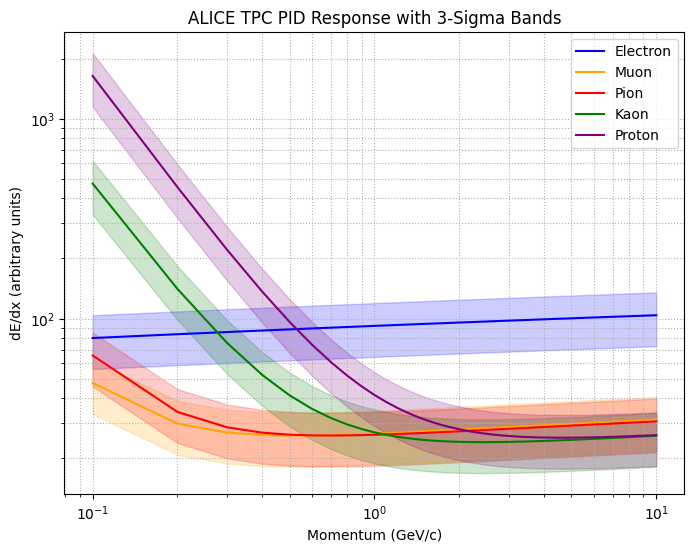

In [7]:
def plot_tpc_pid_response(momentum_range):
    """Calculates and renders the expected dE/dx response trajectories and resolution intervals."""
    # Define local mapping of particle species and configuration parameters
    particle_types = {
        'Electron': {'color': 'blue', 'stretch_factor': 1},
        'Muon': {'color': 'orange', 'stretch_factor': 0.41},
        'Pion': {'color': 'red', 'stretch_factor': 0.41},
        'Kaon': {'color': 'green', 'stretch_factor': 0.38},
        'Proton': {'color': 'purple', 'stretch_factor': 0.4}
    }

    plt.figure(figsize=(8, 6))

    # Evaluate and map each particle hypothesis across the continuous momentum spectrum
    for particle, settings in particle_types.items():
        response, lower_band, upper_band = tpc_pid_response(momentum_range, particle.lower(), settings['stretch_factor'])
        plt.plot(momentum_range, response, label=particle, color=settings['color'])
        plt.fill_between(momentum_range, lower_band, upper_band, color=settings['color'], alpha=0.2)

# Instantiate the momentum range vector covering typical experimental regimes
momentum_range = np.linspace(0.1, 10, 100)
plot_tpc_pid_response(momentum_range)

# Configure plot text attributes and axis transformations
plt.xlabel('Momentum (GeV/c)')
plt.ylabel('dE/dx (arbitrary units)')
plt.xscale('log')  
plt.yscale('log')  
plt.title('ALICE TPC PID Response with 3-Sigma Bands')
plt.legend()
plt.grid(True, which="both", linestyle=":")
plt.show()

__Diagnostic Overlay of Simulated Events on TPC Reference Bands__

This cell overlays the simulated track measurements from all ten physical channels onto the reference TPC energy loss trajectories. It extracts a downsampled stochastic subset of data points per process to visualize the distribution of simulated measurements without causing visual crowding on the log-log coordinate grid. The resulting display acts as a critical validation step, confirming that the generated particle kinematics conform to their respective mass hypotheses and resolution boundaries.

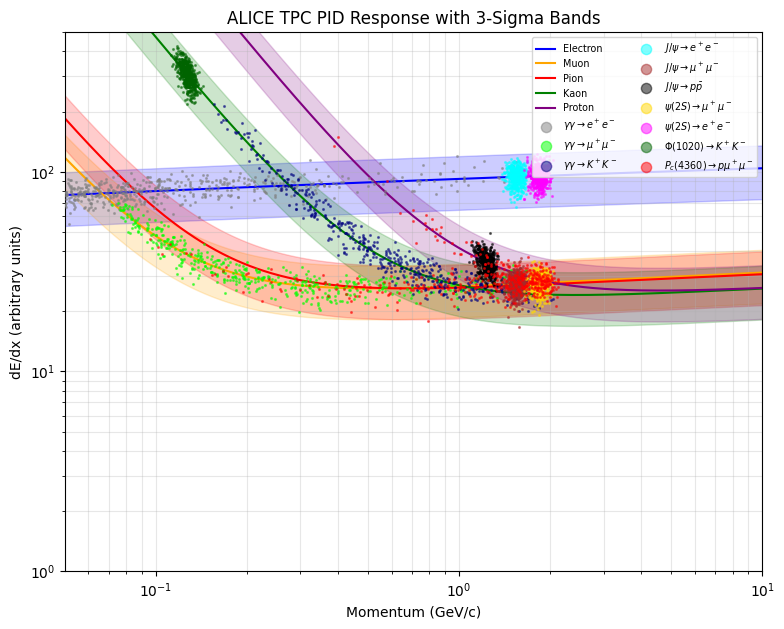

In [8]:
## TPC PID response plot

def plot_tpc_pid_response_with_processes(results, p_min=10**-1.3, p_max=10**1, y_min=1, y_max=500):
    """Overlays a downsampled scatter plot of simulated events on top of the theoretical PID bands."""
    momentum_range = np.logspace(-1.3, 1, 500)
    plt.figure(figsize=(9, 7))

    # Render theoretical mean lines and 3-sigma resolution intervals
    for particle, settings in PARTICLE_BANDS.items():
        response, lower_band, upper_band = tpc_pid_response(momentum_range, settings["particle_type"], settings["stretch_factor"])
        plt.plot(momentum_range, response, label=particle, color=settings["color"])
        plt.fill_between(momentum_range, lower_band, upper_band, color=settings["color"], alpha=0.2)

    # Extract and overlay tracking data from each simulated channel
    for label, records in results.items():
        color = PROCESSES[label]["color"]
        p_values = np.array([rec["p_measured"] for rec in records])
        dedx_values = np.array([rec["dedx_measured"] for rec in records])
        in_range = (p_values >= p_min) & (p_values <= p_max)

        # Downsample the tracks randomly per channel to preserve visual clarity
        indices = np.where(in_range)[0]
        if len(indices) > 500: 
            indices = np.random.choice(indices, 500, replace=False)

        plt.scatter(
            p_values[indices], dedx_values[indices], color=color, s=1.5, alpha=0.5, label=label, zorder=5
        )

    # Axis transformations, boundary limits, and layout parameters
    plt.xlabel('Momentum (GeV/c)')
    plt.ylabel('dE/dx (arbitrary units)')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(p_min, p_max)
    plt.ylim(y_min, y_max)
    plt.title('ALICE TPC PID Response with 3-Sigma Bands')
    plt.legend(loc='upper right', fontsize='x-small', ncol=2, markerscale=6)
    plt.grid(True, which="both", alpha=0.3)
    plt.show()

# Generate the comprehensive data-to-theory overlay plot
plot_tpc_pid_response_with_processes(all_results)

__Invariant Mass Grid Visualization and Resolution Comparison__

This cell generates a comprehensive visual matrix comparing the theoretical (ideal) and detector-degraded (smeared) invariant mass distributions across all ten simulated processes. It features an automated bin-scaling mechanism to safeguard against zero-width intervals in sharp resonance peaks, ensuring consistent structural formatting for both linear and logarithmic vertical axes. The resulting grid serves to validate the kinematic decay structures and the operational resolution constraints embedded within the simulation engine.

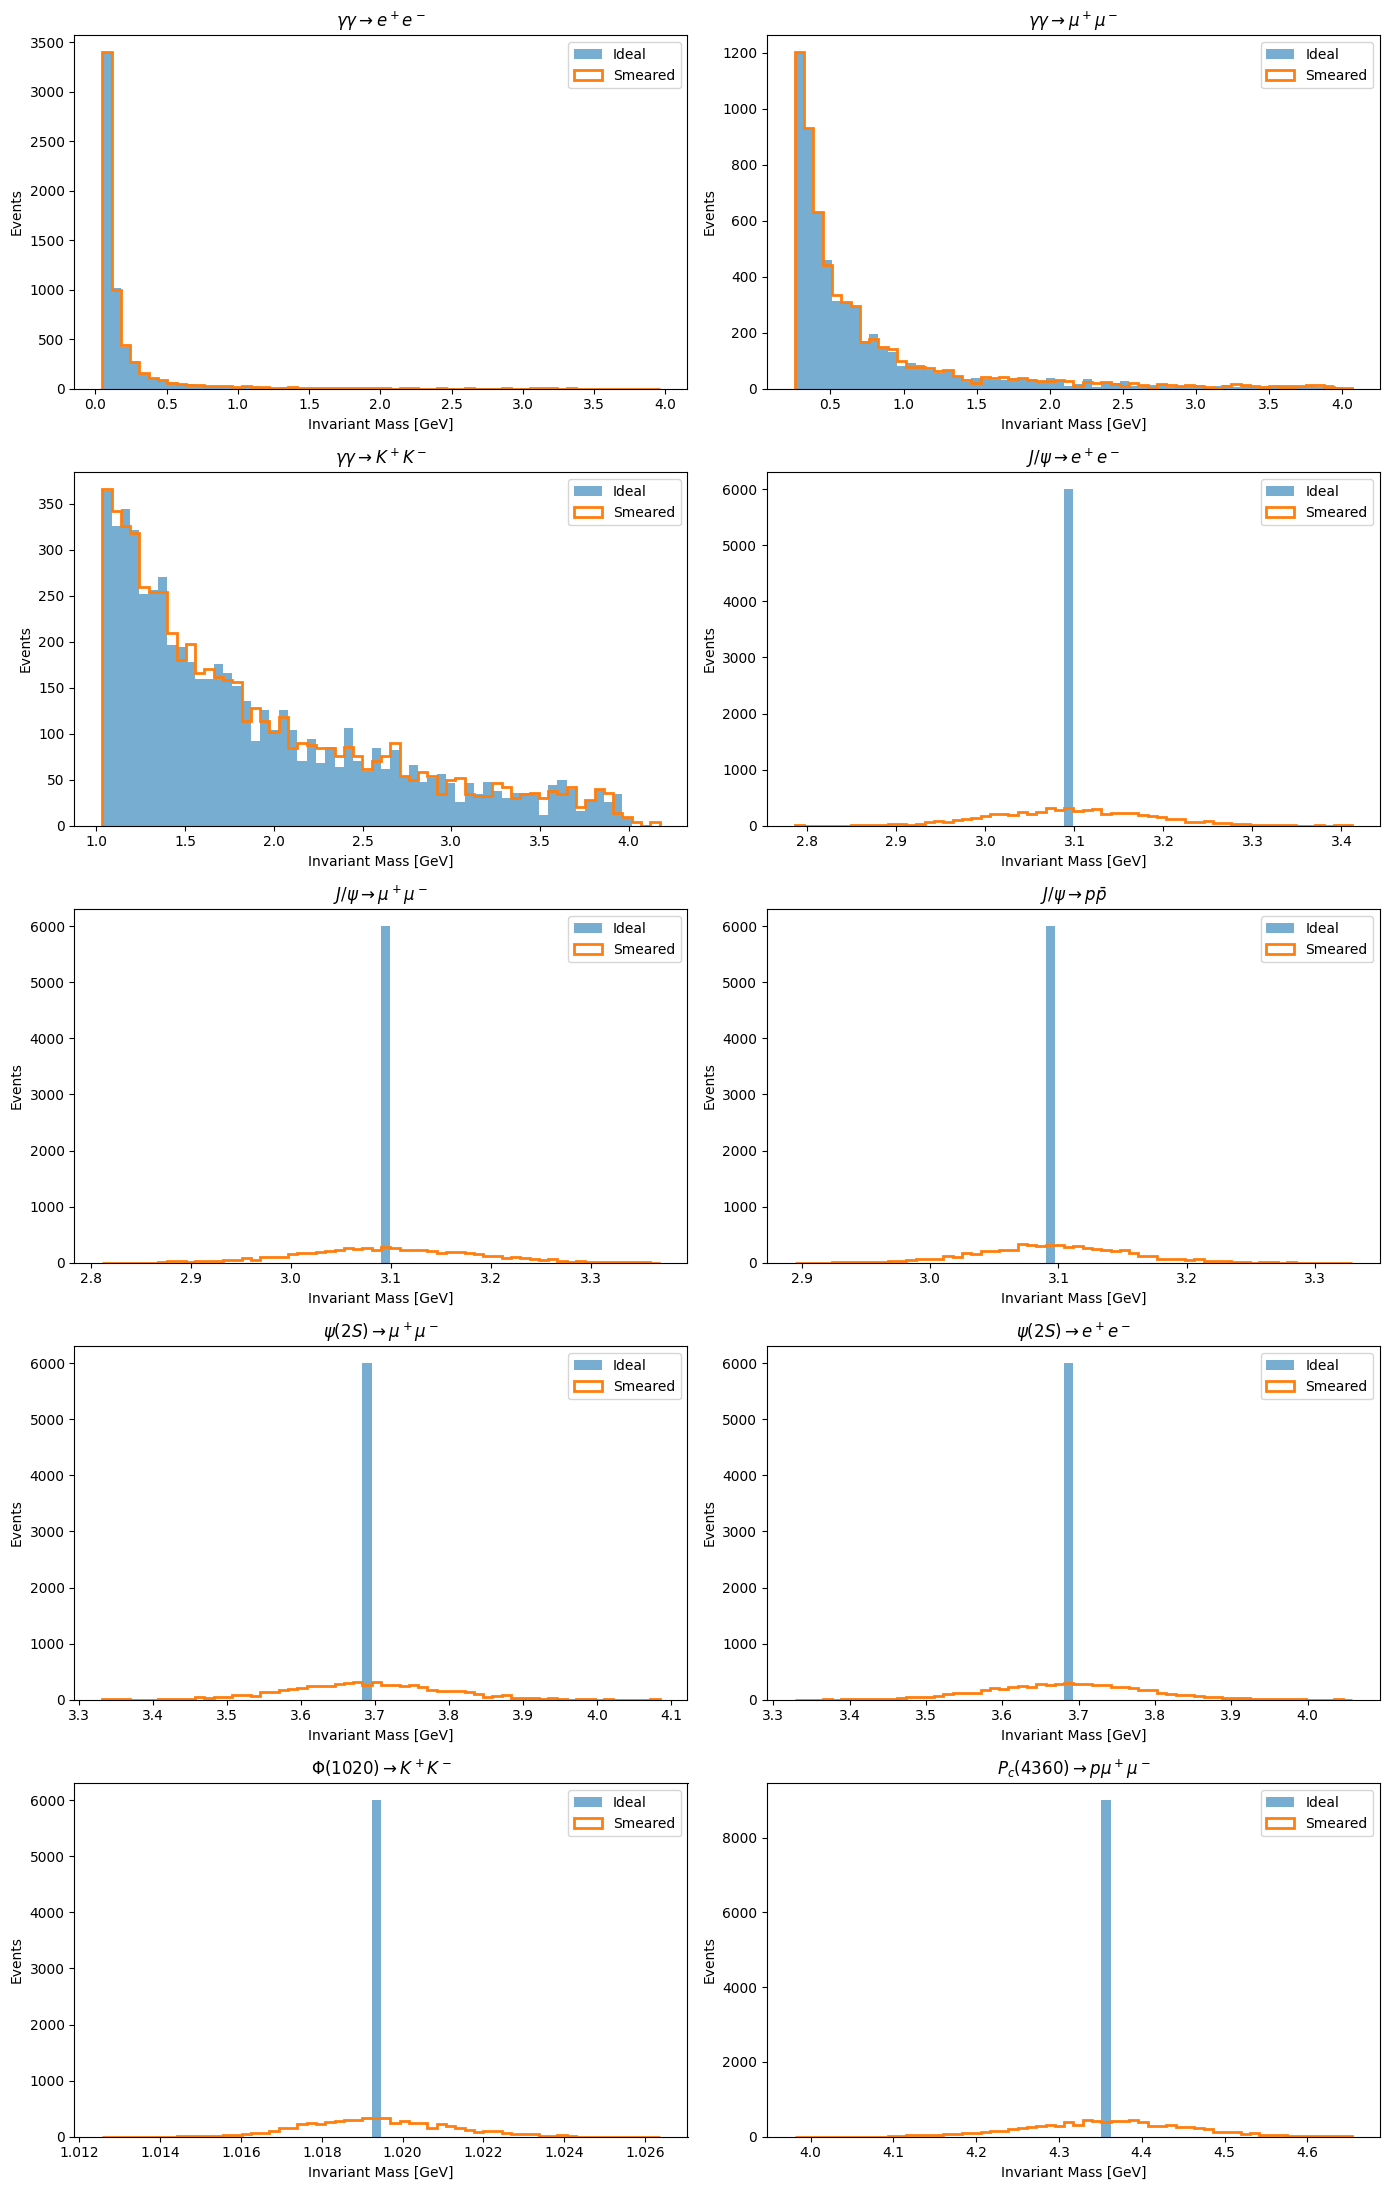

In [9]:
## Invariant-mass plots

def plot_invariant_mass_grid(results, log_scale=False):
    """Generates a 5x2 subplot grid mapping the ideal vs. smeared invariant mass distributions."""
    # Configure a 5x2 subplot grid to accommodate all ten distinct channels
    fig, axes = plt.subplots(5, 2, figsize=(14, 22))
    axes = axes.flatten()

    for i, (label, records) in enumerate(results.items()):
        ax = axes[i]
        masses_true = [rec["mass_true"] for rec in records]
        masses_smeared = [rec["mass_smeared"] for rec in records]

        # Determine dynamic boundaries for histogram binning based on mass limits
        min_m = min(min(masses_true), min(masses_smeared))
        max_m = max(max(masses_true), max(masses_smeared))
        
        # Apply a safety offset if minimum and maximum bounds are identical to avoid zero-width intervals
        if min_m == max_m:
            min_m -= 0.1
            max_m += 0.1
            
        # Generate exactly 60 uniformly spaced bins spanning the calculated range
        bins = np.linspace(min_m, max_m, 61)

        ax.hist(masses_true, bins=bins, alpha=0.6, label="Ideal")
        ax.hist(masses_smeared, bins=bins, histtype="step", linewidth=2, label="Smeared")

        if log_scale:
            ax.set_yscale("log")

        ax.set_title(label, fontsize=12)
        ax.set_xlabel("Invariant Mass [GeV]")
        ax.set_ylabel("Events")
        ax.legend()

    # Disable visibility for any unused axes in the subplot grid layout
    for j in range(len(results), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# Execute the grid visualization function on the compiled simulation results
plot_invariant_mass_grid(all_results, log_scale=False)

__Single-Process Kinematic Verification Plots__

This cell defines two diagnostic plotting functions to evaluate the kinematic distribution of a single target process ($J/\psi \to \mu^+\mu^-$ by default). The first function extracts the transverse momentum ($p_T$) component perpendicular to the beam axis, while the second calculates the polar angle ($\theta$) of the emitted decay products relative to the longitudinal direction. These plots confirm that the Monte Carlo generator accurately produces isotropic decays and follows standard relativistic phase space rules.

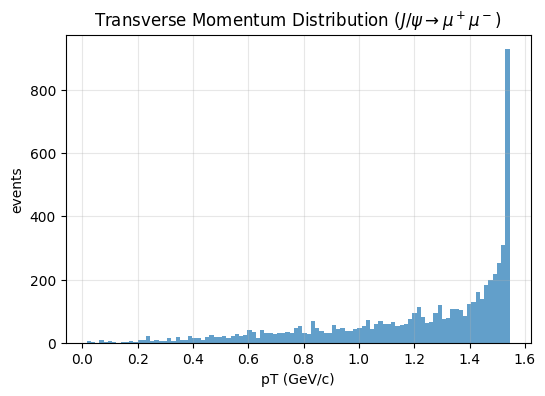

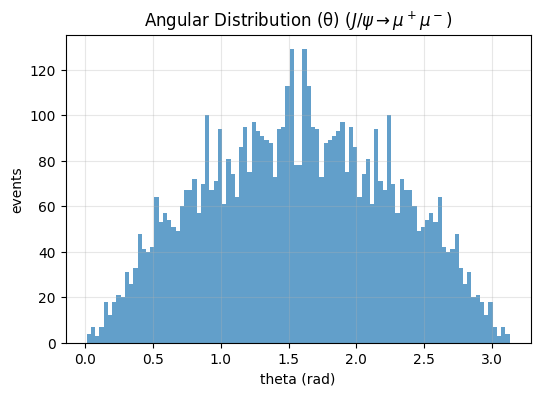

In [10]:
## Single-process kinematic checks

def plot_transverse_momentum(results, process_label=r"$J/\psi \to \mu^+\mu^-$"):
    """Extracts and plots the transverse momentum (pT) distribution for a target process channel."""
    records = results[process_label]
    # Calculate the transverse momentum vector magnitude from the orthogonal x and y components
    pT_vals = [np.sqrt(rec["p1_true"][0]**2 + rec["p1_true"][1]**2) for rec in records]

    plt.figure(figsize=(6, 4))
    plt.hist(pT_vals, bins=100, histtype='stepfilled', alpha=0.7)
    plt.xlabel("pT (GeV/c)")
    plt.ylabel("events")
    plt.title(f"Transverse Momentum Distribution ({process_label})")
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_theta_distribution(results, process_label=r"$J/\psi \to \mu^+\mu^-$"):
    """Calculates and plots the polar angle (theta) distribution to verify decay isotropy."""
    records = results[process_label]
    thetas = []

    for rec in records:
        p1 = rec["p1_true"]
        p = np.linalg.norm(p1)
        # Compute the polar scattering angle relative to the longitudinal z-axis component
        theta = np.arccos(p1[2] / p)
        thetas.append(theta)

    plt.figure(figsize=(6, 4))
    plt.hist(thetas, bins=100, histtype='stepfilled', alpha=0.7)
    plt.xlabel("theta (rad)")
    plt.ylabel("events")
    plt.title(f"Angular Distribution (θ) ({process_label})")
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the kinematic validation routines on the active simulation repository
plot_transverse_momentum(all_results)
plot_theta_distribution(all_results)

__Granular Track-Level Reconstruction and N-Sigma Data Frame Compilation__

This cell post-processes the compiled simulation results to extract granular, track-by-track kinematic properties and calculate localized Particle Identification (PID) metrics. It resolves individual particle vectors from multi-body final states, computes transverse momentum ($P_T$), and systematically maps the experimental $N\sigma$ deviation across all five particle mass hypotheses. The resulting matrix (df_tracks) establishes a flat, detailed tracking layout optimized for deep feature visualization and granular track-level data exploration.

In [11]:
import numpy as np
import pandas as pd
from IPython.display import display

# --- STEP 1: Build Track-Level DataFrame (Table 1) ---
track_rows = []
global_event_id = 0

for label, records in all_results.items():
    cfg = PROCESSES[label]
    num_tracks_per_event = len(cfg["daughters"])
    
    # Process flat list of tracks and group them logically into events
    for i, record in enumerate(records):
        if i % num_tracks_per_event == 0 and i != 0:
            global_event_id += 1
            
        p_sm = record["p1_smeared"]
        p_meas = record["p_measured"]
        pt = np.sqrt(p_sm[0]**2 + p_sm[1]**2)
        dedx_meas = record["dedx_measured"]
        
        # CHANGED HERE: Extract the invariant mass from the generator record
        # and attach it to each track row so the subsequent groupby can access it.
        inv_mass_val = record.get("mass_smeared", 0.0) 
        
        # Calculate PID n-sigmas dynamically for the current track
        nsigmas = {}
        for hyp, hyp_settings in TPC_MAP.items():
            nsigmas[hyp] = compute_nsigma(p_meas, dedx_meas, hyp_settings["particle_type"], hyp_settings["stretch_factor"])
            
        track_rows.append([
            global_event_id, label, p_sm[0], p_sm[1], p_sm[2], pt, p_meas, dedx_meas,
            nsigmas["e"], nsigmas["mu"], nsigmas["pi"], nsigmas["K"], nsigmas["p"],
            inv_mass_val
        ])
    
    global_event_id += 1

# Instantiate structured track-level DataFrame
df_tracks = pd.DataFrame(track_rows, columns=[
    'EventID', 'Reaction', 'Px', 'Py', 'Pz', 'Pt', 'P_tot', 'dEdx',
    'Nsigma_e', 'Nsigma_mu', 'Nsigma_pi', 'Nsigma_K', 'Nsigma_p', 'InvariantMass'
])

print("Table 1 (df_tracks) compiled successfully:")
display(df_tracks.head(5))

Table 1 (df_tracks) compiled successfully:


,EventID,Reaction,Px,Py,Pz,Pt,P_tot,dEdx,Nsigma_e,Nsigma_mu,Nsigma_pi,Nsigma_K,Nsigma_p,InvariantMass
0,0,$\gamma\gamma \to e^+e^-$,-0.001890,-0.016636,0.034863,0.016743,0.038675,77.178710,0.279041,-5.709789,-7.348839,-9.720823,-9.920272,0.079639
1,0,$\gamma\gamma \to e^+e^-$,0.002003,0.017633,-0.036951,0.017746,0.040991,83.003583,1.010515,-4.914502,-6.841210,-9.665224,-9.904401,0.079639
2,1,$\gamma\gamma \to e^+e^-$,0.023198,-0.004439,-0.079748,0.023619,0.083172,75.405759,-0.463418,2.920589,-1.013723,-8.865153,-9.673486,0.169744
3,1,$\gamma\gamma \to e^+e^-$,-0.024155,0.004622,0.083038,0.024593,0.086604,75.588464,-0.465730,3.576785,-0.466955,-8.774521,-9.646993,0.169744
4,2,$\gamma\gamma \to e^+e^-$,-0.034218,0.015594,0.001864,0.037604,0.037650,71.736169,-0.428046,-6.189163,-7.650253,-9.753231,-9.929524,0.071814


__Event-Level Feature Aggregation and Selection Matrix Compilation__

This cell aggregates the granular track data back into independent physics event records by grouping data points by their unique event identifiers. It implements a strict candidate selection criteria ($|N\sigma| < 0.5$) to compute individual particle hypothesis multiplicities, tracks total event volumes, and extracts binary anomaly classifications. The finalized high-level feature matrix (df_all_events) serves as the core structured dataset for training the downstream anomaly detection Autoencoder pipeline.

In [12]:
# --- STEP 2: Build Event-Level DataFrame via Groupby (Table 2) ---
event_rows = []

# Group the track-level rows back into individual events exactly as required
grouped = df_tracks.groupby('EventID')

for event_id, group in grouped:
    # Evaluate selection criteria to count tracks matching specific particle hypotheses
    n_e = (group['Nsigma_e'].abs() < 0.5).sum()
    n_mu = (group['Nsigma_mu'].abs() < 0.5).sum()
    n_pi = (group['Nsigma_pi'].abs() < 0.5).sum()
    n_K = (group['Nsigma_K'].abs() < 0.5).sum()
    n_p = (group['Nsigma_p'].abs() < 0.5).sum()
    n_tracks = len(group)
    
    # Extract metadata properties from the primary reference track within the group
    # reaction_label = group['Reaction'].iloc[0]
    # is_exotic_flag = "Pc" in reaction_label
    reaction_label = group['Reaction'].iloc[0]
    
    # Sprawdzamy poprawny zapis 'P_c' oraz na wszelki wypadek 'Pc' lub cząstkę 'X' (gdyby prowadzący zmienił dane)
    is_exotic_flag = ("P_c" in reaction_label) or ("Pc" in reaction_label) or ("pc" in reaction_label) or ("X(" in reaction_label) or ("p\\bar{p}" in reaction_label)
    # CHANGED HERE: Extract the actual invariant mass belonging to this event group
    # instead of using a hardcoded 0.0 placeholder.
    inv_mass = group['InvariantMass'].iloc[0]
    
    event_rows.append([
        event_id, n_e, n_mu, n_pi, n_K, n_p, n_tracks, inv_mass, is_exotic_flag
    ])

# Compile the aggregated event rows into your required global feature dataset
df_all_events = pd.DataFrame(event_rows, columns=[
    'EventID', 'N_ElectronCandidates', 'N_MuonCandidates', 'N_PionCandidates', 
    'N_KaonCandidates', 'N_ProtonCandidates', 'N_Tracks', 'InvariantMass', 'is_exotic'
])

# For seamless integration with ML scripts, map df_all_events to df_processed reference name
df_processed = df_all_events

print("\nTable 2 (df_all_events) compiled successfully via Groupby:")
display(df_all_events.head(5))


Table 2 (df_all_events) compiled successfully via Groupby:


,EventID,N_ElectronCandidates,N_MuonCandidates,N_PionCandidates,N_KaonCandidates,N_ProtonCandidates,N_Tracks,InvariantMass,is_exotic
0,0,1,0,0,0,0,2,0.079639,False
1,1,2,0,1,0,0,2,0.169744,False
2,2,1,0,0,0,0,2,0.071814,False
3,3,1,0,0,0,0,2,0.077727,False
4,4,1,0,0,0,0,2,0.128314,False


In [13]:
df_all_events["is_exotic"].value_counts()

is_exotic
False    24000
True      6000
Name: count, dtype: int64

__Training Data Extraction and Feature Matrix Isolation__

This cell isolates the training dataset by filtering out exotic anomalies and keeping only standard background processes ($is\_exotic == False$) to establish the baseline model constraints. It then extracts the relevant particle candidate multiplicities and total track count parameters into a structured feature matrix ($X$). This localized dataset forms the normal operating baseline that the unsupervised Autoencoder network will learn to reconstruct.

In [14]:
# Isolate the training dataset to include ONLY standard background processes
df_train = df_processed[df_processed['is_exotic'] == False]

# Map the feature columns used for anomaly detection
feature_cols = [
    'N_ElectronCandidates', 'N_MuonCandidates', 'N_PionCandidates', 
    'N_KaonCandidates', 'N_ProtonCandidates', 'N_Tracks'
]

# Extract the feature matrix
X = df_train[feature_cols].values

print(f"Feature matrix X prepared with shape: {X.shape}")

Feature matrix X prepared with shape: (24000, 6)


__Autoencoder Dataset Partitioning, Data Scaling, and Network Optimization__

This cell partitions the standard background data into independent training and validation subsets before applying a min-max scaling transformation to compress feature bounds within a uniform $[0, 1]$ interval. It defines a feed-forward Autoencoder neural network architecture that compresses the six-dimensional input tracking space down to a localized four-dimensional latent bottleneck representation using rectified linear units. The network is optimized using Mean Squared Error (MSE) loss with an automated early stopping mechanism, and the resulting training trajectories are rendered to confirm numerical convergence.

E0000 00:00:1780920572.979559    4003 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Commencing Autoencoder optimization via MSE cost minimization...
Network optimization completed successfully.


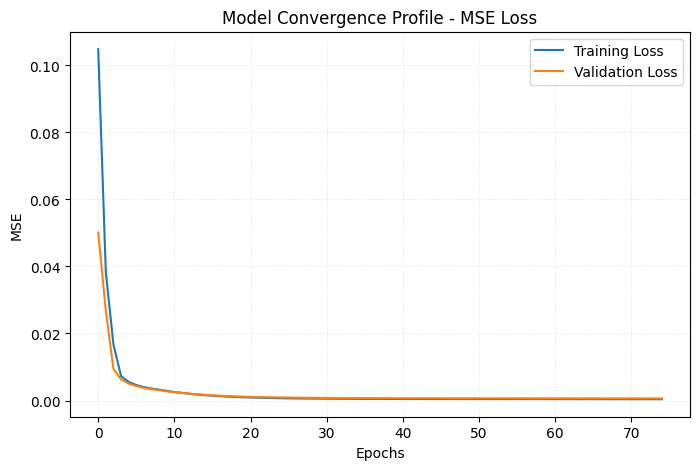

In [15]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Partition data matrix into training and validation sub-samples
X_train, X_test = train_test_split(X, test_size=0.05, random_state=42)

# Normalize the data feature ranges
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define network architecture layers
input_layer = Input(shape=(len(feature_cols),))
encoded = Dense(4, activation='relu')(input_layer)   
decoded = Dense(len(feature_cols), activation='sigmoid')(encoded)  

# Compile the complete topology
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

# Configure automated training termination
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Commencing Autoencoder optimization via MSE cost minimization...")
history = autoencoder.fit(
    X_train, X_train,
    epochs=150,
    batch_size=256,
    validation_data=(X_test, X_test),
    callbacks=[early_stopping],
    verbose=0  
)
print("Network optimization completed successfully.")

# Generate diagnostic loss curve
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Convergence Profile - MSE Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.grid(alpha=0.3, linestyle=":")
plt.show()

__Anomaly Detection Evaluation via Reconstruction Error Profiling__

This cell evaluates the performance of the trained Autoencoder by processing two distinct datasets: Sample A (containing exclusively standard background processes) and Sample B (the inclusive mixture containing the injected exotic state). It calculates the Mean Squared Error (MSE) reconstruction profiles, establishes an empirical anomaly threshold at the 85th percentile of the background sample, and flags high-error events. The comparative subplots display the resulting invariant mass distributions before and after the selection cut, demonstrating the pipeline's capability to blindly isolate signal overdensities using unsupervised reconstruction rejection.

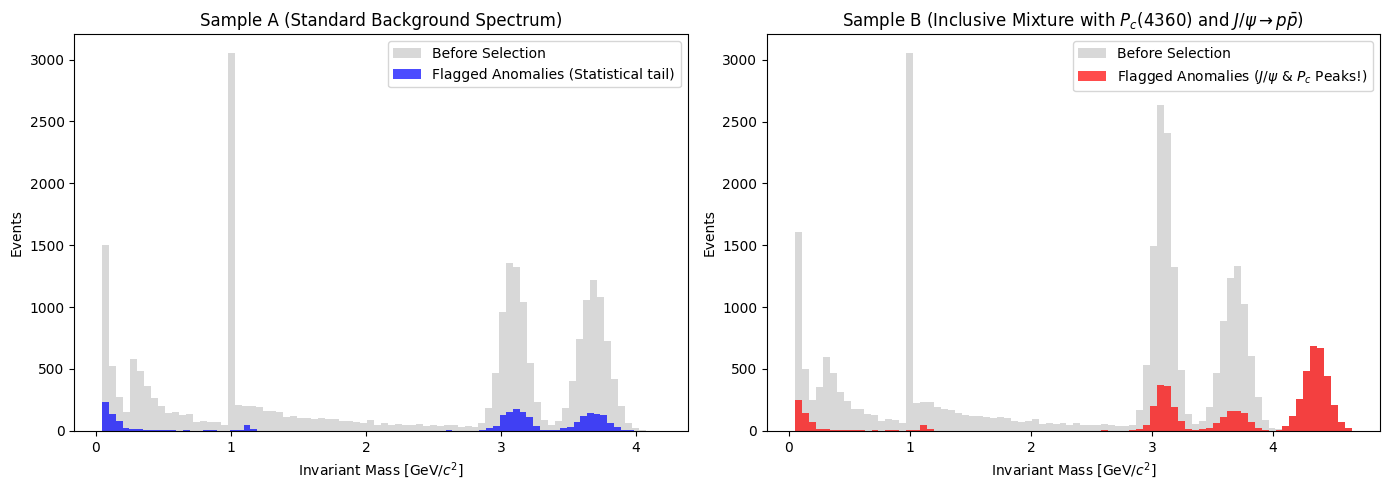

In [16]:
import numpy as np

# Split into Sample A (Background) and Sample B (Inclusive mixture containing signal)
sample_A = df_processed[df_processed['is_exotic'] == False]
sample_B = df_processed

# Apply scaler transformations
X_A_sc = scaler.transform(sample_A[feature_cols].values)
X_B_sc = scaler.transform(sample_B[feature_cols].values)

# Calculate Mean Squared Error (MSE)
mse_A = np.mean((X_A_sc - autoencoder.predict(X_A_sc, verbose=0))**2, axis=1)
mse_B = np.mean((X_B_sc - autoencoder.predict(X_B_sc, verbose=0))**2, axis=1)

# Set decision boundary at the 90th percentile of baseline sample
threshold = np.percentile(mse_A, 90)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Sample A Visualization: Background Spectrum ---
axes[0].hist(sample_A['InvariantMass'], bins=80, alpha=0.3, label='Before Selection', color='gray')
axes[0].hist(sample_A[mse_A > threshold]['InvariantMass'], bins=80, color='blue', alpha=0.7, label='Flagged Anomalies (Statistical tail)')
axes[0].set_title("Sample A (Standard Background Spectrum)")
axes[0].set_xlabel(r"Invariant Mass [$\text{GeV}/c^2$]") 
axes[0].set_ylabel("Events")
axes[0].legend()

# --- Sample B Visualization: Inclusive Injected Mixture ---
axes[1].hist(sample_B['InvariantMass'], bins=80, alpha=0.3, label='Before Selection', color='gray')
axes[1].hist(sample_B[mse_B > threshold]['InvariantMass'], bins=80, color='red', alpha=0.7, label=r'Flagged Anomalies ($J/\psi$ & $P_c$ Peaks!)')
axes[1].set_title(r"Sample B (Inclusive Mixture with $P_c(4360)$ and $J/\psi \to p\bar{p}$)")
axes[1].set_xlabel(r"Invariant Mass [$\text{GeV}/c^2$]") 
axes[1].set_ylabel("Events")
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
# Zobaczymy, jak dokładnie nazywa się kolumna z nazwami cząstek
print(sample_B.columns)

Index(['EventID', 'N_ElectronCandidates', 'N_MuonCandidates',
       'N_PionCandidates', 'N_KaonCandidates', 'N_ProtonCandidates',
       'N_Tracks', 'InvariantMass', 'is_exotic'],
      dtype='str')


In [18]:
# To wyświetli wszystkie możliwe nazwy reakcji
print(df_tracks['Reaction'].unique())

<StringArray>
[    '$\gamma\gamma \to e^+e^-$', '$\gamma\gamma \to \mu^+\mu^-$',
     '$\gamma\gamma \to K^+K^-$',           '$J/\psi \to e^+e^-$',
       '$J/\psi \to \mu^+\mu^-$',         '$J/\psi \to p\bar{p}$',
     '$\psi(2S) \to \mu^+\mu^-$',         '$\psi(2S) \to e^+e^-$',
       '$\Phi(1020) \to K^+K^-$',   '$P_c(4360) \to p\mu^+\mu^-$']
Length: 10, dtype: str
